# Texture mapping

[10, 90, 90, 10] [90, 60, 30, 9]


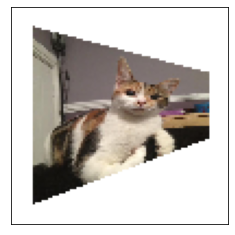

In [97]:
import numpy as np
import matplotlib.pyplot as plt     
from myst_nb import glue
plt.rcParams['text.usetex'] = True
import matplotlib.image as mpimg


def pixelcoordinates(X, Y, Nx, Ny):
    X = [int(x * Nx) for x in X]
    Y = [int((1 - y) * Nx) for y in Y]
    return X, Y


def texturemapper(R, T, X, Y):
    
    # Texture space co-ordinates
    rows, cols, _ = T.shape
    U, V = [0, cols, cols, 0], [rows, rows, 0, 0]
    
    # Generate edge table
    n = len(X)
    ET = []
    j = n - 1
    for i in range(n):
        if Y[i] < Y[j]:
            imin, imax = i, j
        elif Y[i] > Y[j]:
            imin, imax = j, i
        else:
            j = i
            continue
            
        dx, dy = abs(X[imin] - X[imax]), abs(Y[imin] - Y[imax])
        if X[imin] > X[imax]:
            xstep = -1
        else:
            xstep = 1
            
        du, dv = U[imax] - U[imin], V[imax] - V[imin]
        if dy != 0:
            du, dv = du / dy, dv / dy
            
        edge = {'x' : X[imin], 'N' : 0, 'dx' : abs(dx), 'dy' : abs(dy), 
                'ymin' : Y[imin], 'ymax' : Y[imax], 'xstep' : xstep,
                'u' : U[imin], 'v' : V[imin], 'du' : du, 'dv' : dv}
        ET.append(edge)
        j = i
        
    # Loop through scanlines
    y = min(Y)
    AET = []
    n = 1
    while len(ET) > 0 or len(AET) > 0:
        
        # Move edges from ET to AET whose ymin = y
        i = 0
        while i < len(ET):
            if ET[i]["ymin"] == y:
                AET.append(ET.pop(i))
            else:
                i += 1
        
        # Sort AET by x value
        AET = sorted(AET, key=lambda d: d['x']) 

        # Fill scanline
        i = 0
        xL, xR = AET[0]['x'], AET[1]['x']
        uL, vL = AET[0]['u'], AET[0]['v']
        uR, vR = AET[1]['u'], AET[1]['v']
        du, dv = 0, 0
        if xR != xL:
            du, dv = (uR - uL) / (xR - xL), (vR - vL) / (xR - xL)

        u, v = uL, vL
        for x in range(xL, xR + 1):
            R[y, x, :] = T[min(int(v), rows - 1), min(int(u), cols - 1),  :]
            u, v = u + du, v + dv
      
        # Remove edges from AET whose ymax = y
        i = 0
        while i < len(AET):
            if AET[i]["ymax"] == y:
                AET.pop(i)
            else:
                i += 1
        
        # Update N and x
        for edge in AET:
            edge['N'] += edge['dx']
            edge['u'] += edge['du']
            edge['v'] += edge['dv']
            while edge['N'] >= edge['dy']:
                edge['N'] -= edge['dy']
                edge['x'] += edge['xstep']

        y += 1       
              
    return R 
          

blue = [210, 210, 255]
Nx, Ny = 100, 100
X = [0.1, 0.9, 0.9, 0.1]
Y = [0.1, 0.4, 0.7, 0.9]
X, Y = pixelcoordinates(X, Y, Nx, Nx)
print(X, Y)

img = 255 * np.ones((Nx, Ny, 3)).astype(int)

fig, ax = plt.subplots()
     
texture = mpimg.imread("../images/cavendish.jpg")
img = texturemapper(img, texture, X, Y)

plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()